# CIGALE + TAMIS for one COSMOS2020 galaxy

This notebook fits the representative object saved by notebook 00. It uses the same
delayed-tau CIGALE model as the catalog MAF tutorial, but performs an object-specific
posterior calculation with CompoSED's self-contained TAMIS implementation.
Because every prior in this example is continuous, the mixed proposal has
no categorical block and reduces to ordinary continuous TAMIS.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import sys
import numpy as np

REPO_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "composed").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
DATA_PATH = REPO_ROOT / "notebooks/tutorials/data/cosmos2020_ugrizYJH_100k.npz"
if not DATA_PATH.exists():
    raise FileNotFoundError("Run 00_prepare_cosmos2020_ugrizYJH.ipynb first.")

with np.load(DATA_PATH, allow_pickle=False) as catalog:
    flux = catalog["flux_maggies"]
    sigma = catalog["sigma_maggies"]
    z_reference = catalog["lp_zbest"]
    mass_reference = catalog["lp_mass_med"]
    sfr_reference = catalog["lp_sfr_med"]
    dust_reference = catalog["lp_dust"]
    BAND_NAMES = tuple(catalog["band_names"].astype(str))
    FILTER_NAMES = tuple(catalog["sedpy_filter_names"].astype(str))
    SINGLE_OBJECT = int(catalog["single_object_position"])

print(f"Loaded {flux.shape[0]:,} galaxies in {flux.shape[1]} bands")
print("Single tutorial object:", SINGLE_OBJECT, "z_ref=", z_reference[SINGLE_OBJECT])

from sedpy.observate import load_filters
from composed.filters import FilterSet

filters = FilterSet(load_filters(list(FILTER_NAMES)), names=BAND_NAMES)


Loaded 100,000 galaxies in 8 bands
Single tutorial object: 36096 z_ref= 1.0001


In [2]:
from composed import DelayedTauSFH, EmpiricalPhotometricNoise, Gaussian, Problem, SEDDataset, UniformPrior
from composed.backends.cigale import build_cigale_backend_and_parameter_space

sfh = DelayedTauSFH(age="age_fraction", age_kind="fraction_of_universe", tau="tau_gyr")
modules = ["bc03", "nebular", "dustatt_modified_starburst", "redshifting"]
module_parameters = {
    "bc03": {"imf": 1, "metallicity": 0.02, "separation_age": 10},
    "nebular": {
        "logU": -2.0, "zgas": 0.019, "ne": 100.0, "f_esc": 0.0,
        "f_dust": 0.0, "lines_width": 300.0, "emission": True,
    },
    "dustatt_modified_starburst": {
        "E_BV_lines": {"range": [0.0, 0.8]}, "E_BV_factor": 0.44,
        "uv_bump_wavelength": 217.5, "uv_bump_width": 35.0,
        "uv_bump_amplitude": 0.0, "powerlaw_slope": 0.0,
        "Ext_law_emission_lines": 1, "Rv": 3.1, "filters": "B_B90 & V_B90",
    },
    "redshifting": {"redshift": {"range": [0.05, 5.0]}},
}
backend, parameters = build_cigale_backend_and_parameter_space(
    modules,
    module_parameters,
    additional_priors={
        "log10_mass": UniformPrior(6.0, 13.0),
        "age_fraction": UniformPrior(0.30, 0.95),
        "tau_gyr": UniformPrior(0.1, 8.0),
    },
    sfh=sfh,
    photometry_mode="sedpy",
    default_z_key="redshift",
)
FRACTIONAL_MODEL_ERROR = 0.05
sigma_effective = np.sqrt(sigma**2 + (FRACTIONAL_MODEL_ERROR * np.abs(flux))**2)
noise_model = EmpiricalPhotometricNoise(
    sigma, fractional_error=FRACTIONAL_MODEL_ERROR, band_names=BAND_NAMES, flux_unit="maggies"
)
data = SEDDataset(BAND_NAMES, flux[SINGLE_OBJECT], sigma_effective[SINGLE_OBJECT], flux_unit="maggies")
problem = Problem(backend, parameters, data, Gaussian(), filters=filters)


## Fit


In [3]:
from composed import (
    MixedTAMIS, fit, load_inference_result, posterior_summary,
    require_result_matches_problem, save_inference_result,
)

OUTPUT = REPO_ROOT / "outputs/tutorial_cigale_tamis_single"
FORCE = os.environ.get("COMPOSED_TUTORIAL_FORCE", "0") == "1"
result = None
if (OUTPUT / "inference_result.npz").exists() and not FORCE:
    cached_result = load_inference_result(OUTPUT)
    try:
        result = require_result_matches_problem(cached_result, problem)
        print("Loaded saved TAMIS fit for this Problem")
    except ValueError as error:
        print(f"Ignoring stale TAMIS fit: {error}")

if result is None:
    result = fit(
        problem,
        MixedTAMIS(
            n_comp=10,
            T_max=100,
            n_per_iter=1000,
            var0=2.0,
            continuous_transform="auto",
        ),
        seed=61,
    )
    save_inference_result(result, OUTPUT)
tamis_meta = result.metadata.get("sampler_meta", {})
print("Final TAMIS adaptation beta:", np.asarray(tamis_meta.get("betas", [np.nan]))[-1])
print("Posterior-weight ESS:", 1.0 / np.sum(result.weights**2))
posterior_summary(result)


Loaded saved TAMIS fit
Final TAMIS adaptation beta: 0.9595589439193128
Posterior-weight ESS: 2234.087070746469


{'log10_mass': {'q_lo': 10.016178184480216,
  'median': 10.083120999609042,
  'q_hi': 10.143810682744286,
  'map': 10.043556702037861},
 'age_fraction': {'q_lo': 0.4099005234064881,
  'median': 0.5590401098767989,
  'q_hi': 0.7481905232845698,
  'map': 0.38320391416517685},
 'tau_gyr': {'q_lo': 0.70796835552322,
  'median': 1.3662477379533298,
  'q_hi': 4.604365819826466,
  'map': 0.5091577870096546},
 'E_BV_lines': {'q_lo': 0.35982460340120104,
  'median': 0.6520027991116322,
  'q_hi': 0.7627860624797462,
  'map': 0.3743440243496714},
 'redshift': {'q_lo': 0.8734511511984934,
  'median': 0.9113096427821359,
  'q_hi': 0.9499275021952093,
  'map': 0.9424720966112712}}

## Posterior and posterior predictive SED


(<Figure size 800x330 with 1 Axes>,
 array([<Axes: xlabel='wavelength', ylabel='flux [photometry units]'>],
       dtype=object))

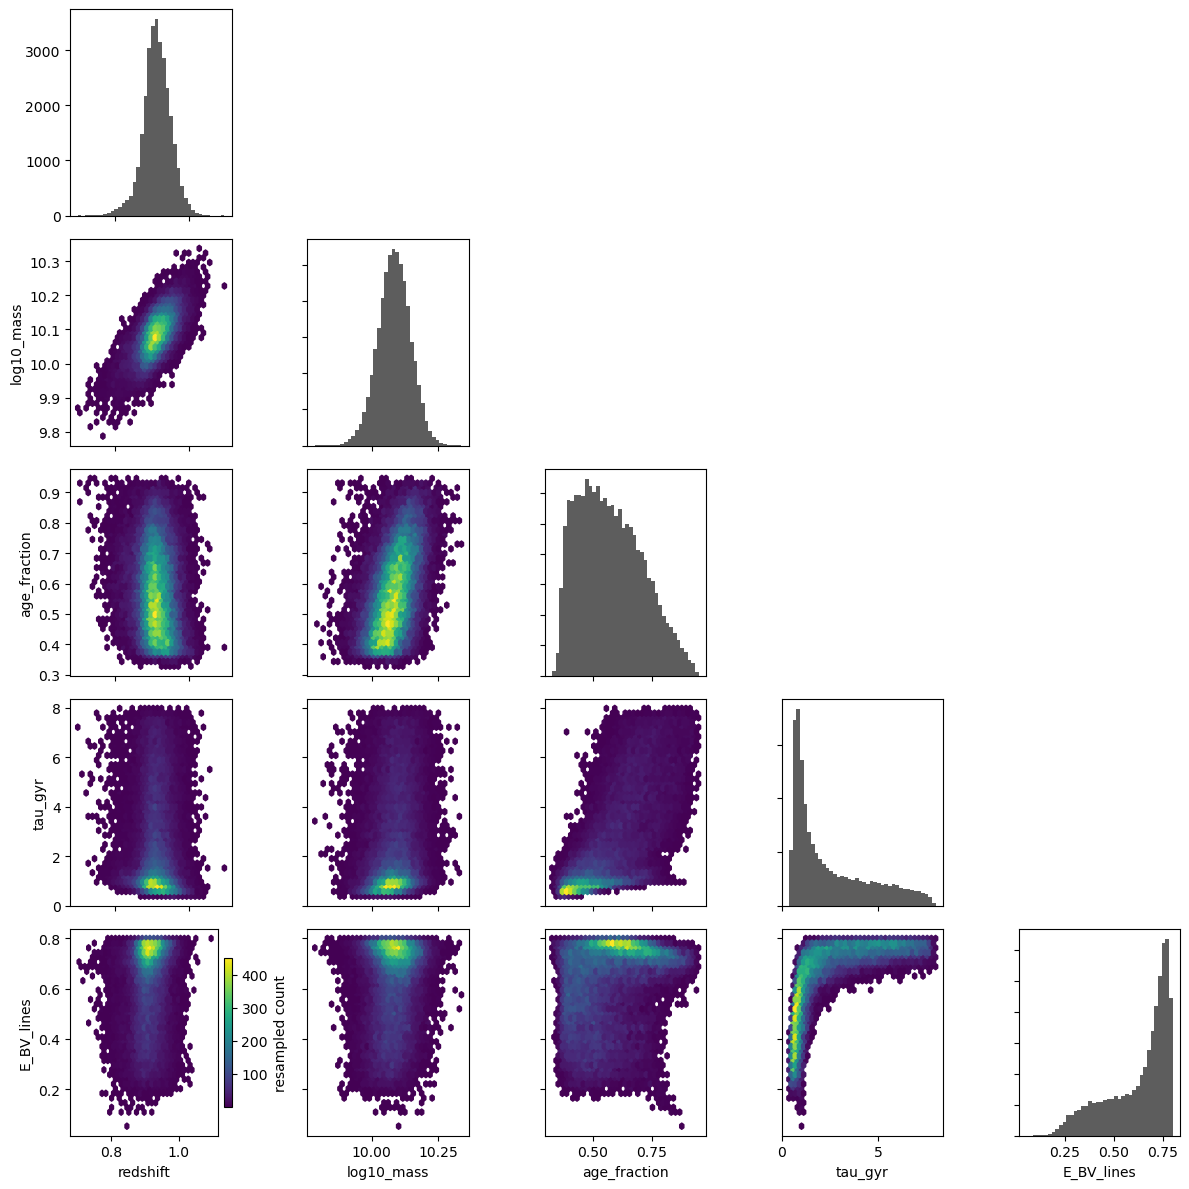

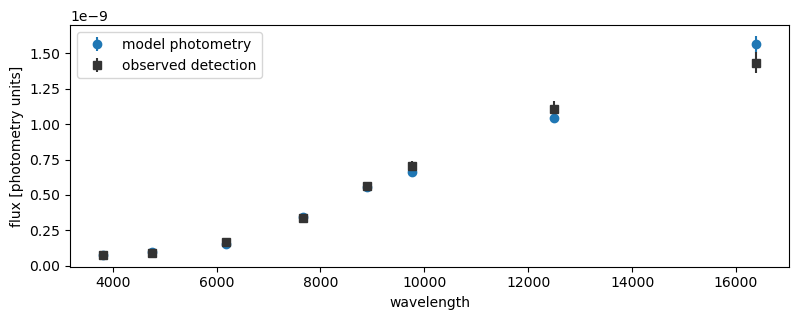

In [4]:
from composed.plot import plot_corner_hexbin, plot_posterior_predictive_sed

plot_corner_hexbin(
    result,
    parameters=["redshift", "log10_mass", "age_fraction", "tau_gyr", "E_BV_lines"],
    max_points=30_000,
)
plot_posterior_predictive_sed(
    result, backend, parameters, photometry=data, filters=filters,
    n_draw=150, seed=62,
)


posterior log10 SFR 16/50/84%: [0.19619807 0.63943375 0.8714837 ]
LePhare reference log10 SFR: 1.09896


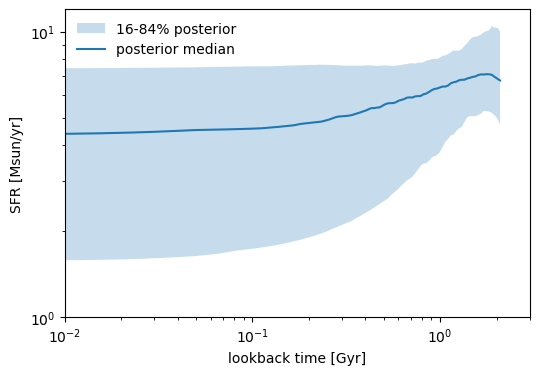

In [5]:
from composed import derive_sfh_quantities

rng = np.random.default_rng(63)
chosen = rng.choice(len(result.samples), size=256, replace=True, p=result.weights)
native_histories = []
current_sfr = []
for theta in result.samples[chosen]:
    derived = derive_sfh_quantities(backend, parameters.to_dict(theta), filters)
    lookback = (derived.time_gyr[-1] - derived.time_gyr)[::-1]
    native_histories.append((lookback, derived.sfr_msun_per_yr[::-1]))
    current_sfr.append(derived.log10_sfr)

max_common_lookback = min(lookback[-1] for lookback, _ in native_histories)
lookback_grid = np.geomspace(0.01, max_common_lookback, 160)
histories = np.asarray([
    np.interp(lookback_grid, lookback, sfr)
    for lookback, sfr in native_histories
])
lo, med, hi = np.quantile(histories, [0.16, 0.5, 0.84], axis=0)
plt.figure(figsize=(6, 4))
plt.fill_between(lookback_grid, lo, hi, alpha=0.25, label="16-84% posterior")
plt.plot(lookback_grid, med, label="posterior median")
plt.xscale("log"); plt.yscale("log")
plt.xlim(0.01, 3.0); plt.ylim(1.0, 12.0)
plt.xlabel("lookback time [Gyr]"); plt.ylabel("SFR [Msun/yr]")
plt.legend(frameon=False)
print("posterior log10 SFR 16/50/84%:", np.quantile(current_sfr, [0.16, 0.5, 0.84]))
print("LePhare reference log10 SFR:", sfr_reference[SINGLE_OBJECT])
